# Production Allocation with the Linear Recovery-Factor Method

When several wells (or fields) are commingled before the custody-transfer meters,
the metered export of **gas**, **oil** and **water** must be *allocated back* to each
source so that production, royalties and ownership shares can be settled fairly.

This notebook demonstrates the `neqsim.process.allocation` package, which performs
**component-resolved back-allocation** using a *linear recovery-factor proxy network*:

1. A rigorous base-case process is run **once** with one common component slate.
2. Frozen per-unit, per-component split factors $f_u(s,k)$ are extracted from that run.
3. Each source is injected on its own and propagated through the linear network by
   **superposition**, giving how much of every custody stream came from each source.

The cost scales with *components × units*, **not** with the number of sources, and the
network handles recycles and reflux (it solves $(I-A_k)\,v=b$ per component).

We build a two-well commingled oil & gas process, allocate the export streams back to
the wells, reproduce the classic per-component **oil/gas recovery factor (ORF)**, and
show how the allocation responds when one well's rate changes.

> Reference theme: the public NeqSim-Colab example
> [`allocationoilandgas2.ipynb`](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/allocationoilandgas2.ipynb),
> which tags components per source. Here we use the faster linear proxy network instead.

## 1. Environment setup

We load NeqSim from the workspace build (`target/classes`) using the devtools helper so
that the latest `neqsim.process.allocation` classes are available without packaging a JAR.

In [1]:
import os
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

from neqsim_dev_setup import neqsim_init, neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)

import numpy as np
import matplotlib.pyplot as plt

print("NeqSim ready from", PROJECT_ROOT)

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim2
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim2\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim2\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim2\target\neqsim-3.10.0.jar



JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes


All NeqSim classes imported OK


NeqSim ready from C:\Users\ESOL\Documents\GitHub\neqsim2


In [2]:
# Resolve the Java classes we use (full paths keep this robust across NeqSim versions).
SystemSrkEos = ns.JClass("neqsim.thermo.system.SystemSrkEos")
Stream = ns.JClass("neqsim.process.equipment.stream.Stream")
Mixer = ns.JClass("neqsim.process.equipment.mixer.Mixer")
Separator = ns.JClass("neqsim.process.equipment.separator.Separator")
ThrottlingValve = ns.JClass("neqsim.process.equipment.valve.ThrottlingValve")
ProcessSystem = ns.JClass("neqsim.process.processmodel.ProcessSystem")
SourceAllocator = ns.JClass("neqsim.process.allocation.SourceAllocator")
ProductType = ns.JClass("neqsim.process.allocation.ProductType")
print("Allocation classes loaded.")

Allocation classes loaded.


## 2. Build a two-well commingled process

Two wells with **different gas/oil ratios** are commingled, then flashed in a two-stage
separation train:

```
 Well-A (gas-rich) ┐
                   ├─ Commingling ─ HP Separator ─ gas ──► ExportGas  (GAS, custody)
 Well-B (oil-rich) ┘                     │ liquid
                                          ▼
                                  Throttling valve
                                          │
                                   LP Separator ─ gas ──► LPGas    (GAS, custody)
                                          │ liquid
                                          └─────────────► StabOil  (OIL, custody)
```

The network is acyclic, so the per-component linear solve is exact. The build is wrapped
in a function so we can re-run it at different rates for the sensitivity study.

In [3]:
# A realistic light component slate shared by both wells (defined components keep the
# demo robust and fast; TBP fractions could be substituted for a real assay).
COMPONENTS = [
    "nitrogen", "CO2", "methane", "ethane", "propane",
    "i-butane", "n-butane", "i-pentane", "n-pentane",
    "n-hexane", "nC8", "nC10", "nC12",
]

# Mole fractions for a gas-rich well and an oil/condensate-rich well.
WELL_A = [0.010, 0.020, 0.870, 0.045, 0.025, 0.006, 0.008, 0.003, 0.003, 0.004, 0.002, 0.001, 0.003]
WELL_B = [0.004, 0.015, 0.300, 0.060, 0.055, 0.020, 0.030, 0.020, 0.025, 0.090, 0.120, 0.140, 0.121]


def make_fluid(mole_fractions):
    fluid = SystemSrkEos(298.15, 60.0)
    for name, z in zip(COMPONENTS, mole_fractions):
        fluid.addComponent(name, float(z))
    fluid.setMixingRule("classic")
    return fluid


def build_process(rate_a_kghr=120000.0, rate_b_kghr=90000.0):
    """Assemble and run the two-well commingled process. Returns (process, handles dict)."""
    process = ProcessSystem()

    feed_a = Stream("Well-A", make_fluid(WELL_A))
    feed_a.setFlowRate(rate_a_kghr, "kg/hr")
    feed_a.setTemperature(45.0, "C")
    feed_a.setPressure(60.0, "bara")
    process.add(feed_a)

    feed_b = Stream("Well-B", make_fluid(WELL_B))
    feed_b.setFlowRate(rate_b_kghr, "kg/hr")
    feed_b.setTemperature(45.0, "C")
    feed_b.setPressure(60.0, "bara")
    process.add(feed_b)

    mixer = Mixer("Commingling")
    mixer.addStream(feed_a)
    mixer.addStream(feed_b)
    process.add(mixer)

    hp_sep = Separator("HP Separator", mixer.getOutletStream())
    process.add(hp_sep)

    export_gas = Stream("ExportGas", hp_sep.getGasOutStream())
    process.add(export_gas)

    valve = ThrottlingValve("LP Valve", hp_sep.getLiquidOutStream())
    valve.setOutletPressure(8.0, "bara")
    process.add(valve)

    lp_sep = Separator("LP Separator", valve.getOutletStream())
    process.add(lp_sep)

    lp_gas = Stream("LPGas", lp_sep.getGasOutStream())
    process.add(lp_gas)
    stab_oil = Stream("StabOil", lp_sep.getLiquidOutStream())
    process.add(stab_oil)

    process.run()
    handles = {
        "feed_a": feed_a,
        "feed_b": feed_b,
        "hp_sep": hp_sep,
        "lp_sep": lp_sep,
    }
    return process, handles


process, h = build_process()
print("Base case solved.")
print("HP gas    : %8.1f kg/hr" % h["hp_sep"].getGasOutStream().getFlowRate("kg/hr"))
print("LP gas    : %8.1f kg/hr" % h["lp_sep"].getGasOutStream().getFlowRate("kg/hr"))
print("Stab. oil : %8.1f kg/hr" % h["lp_sep"].getLiquidOutStream().getFlowRate("kg/hr"))

Base case solved.
HP gas    : 116076.7 kg/hr
LP gas    :   7276.5 kg/hr
Stab. oil :  86646.7 kg/hr


## 3. Allocate the export streams back to the wells

We register the two wells as **sources** and the three terminal streams as **custody
outlets**, tagging each with its product type. Custody outlets are tagged on the
*producing equipment's* outlet stream (the separator gas/liquid ports), which the
allocator matches by object identity.

In [4]:
def allocate(process, handles):
    allocator = SourceAllocator()
    allocator.setBaseCase(process)
    allocator.addSource("Well-A", handles["feed_a"])
    allocator.addSource("Well-B", handles["feed_b"])
    allocator.addCustodyOutlet("ExportGas", handles["hp_sep"].getGasOutStream(), ProductType.GAS)
    allocator.addCustodyOutlet("LPGas", handles["lp_sep"].getGasOutStream(), ProductType.GAS)
    allocator.addCustodyOutlet("StabOil", handles["lp_sep"].getLiquidOutStream(), ProductType.OIL)
    return allocator.allocate()


result = allocate(process, h)

sources = [str(s) for s in result.getSourceNames()]
custody = [str(c) for c in result.getCustodyNames()]
components = [str(c) for c in result.getComponentNames()]
print("Sources :", sources)
print("Custody :", custody)
print("Max solver residual: %.2e" % result.getMaxResidual())

Sources : ['Well-A', 'Well-B']
Custody : ['ExportGas', 'LPGas', 'StabOil']
Max solver residual: 0.00e+00


In [5]:
# Source -> custody allocation matrix (kg/hr).
print("Allocation matrix [kg/hr]")
header = "%-10s" % "" + "".join("%12s" % c for c in custody) + "%12s" % "TOTAL"
print(header)
for s in sources:
    row = "%-10s" % s
    for c in custody:
        row += "%12.1f" % result.getAllocatedFlow(s, c, "kg/hr")
    row += "%12.1f" % result.getSourceTotal(s, "kg/hr")
    print(row)
totals = "%-10s" % "TOTAL"
for c in custody:
    totals += "%12.1f" % result.getCustodyTotal(c, "kg/hr")
print(totals)

Allocation matrix [kg/hr]
             ExportGas       LPGas     StabOil       TOTAL
Well-A        101487.9      5816.6     12695.5    120000.0
Well-B         14588.8      1460.0     73951.2     90000.0
TOTAL         116076.7      7276.5     86646.7


In [6]:
# Per-source product split (gas vs oil) in tonnes/day.
print("%-10s %12s %12s" % ("Source", "Gas [t/d]", "Oil [t/d]"))
for s in sources:
    gas_td = result.getProductAllocation(s, ProductType.GAS, "kg/day") / 1000.0
    oil_td = result.getProductAllocation(s, ProductType.OIL, "kg/day") / 1000.0
    print("%-10s %12.1f %12.1f" % (s, gas_td, oil_td))

field_gas = result.getProductTotal(ProductType.GAS, "kg/day") / 1000.0
field_oil = result.getProductTotal(ProductType.OIL, "kg/day") / 1000.0
print("\nField total gas: %.1f t/d   oil: %.1f t/d" % (field_gas, field_oil))

Source        Gas [t/d]    Oil [t/d]
Well-A           2575.3        304.7
Well-B            385.2       1774.8

Field total gas: 2960.5 t/d   oil: 2079.5 t/d


## 4. Component recovery factors (ORF)

The **component recovery factor** at a custody outlet is the share of a component's total
production that leaves through that outlet. For a gas/oil split this is the classic
*oil/gas recovery factor (ORF)*. Light ends recover almost entirely to gas; heavy ends
stay in the stabilised oil — exactly the separation physics the base case captured.

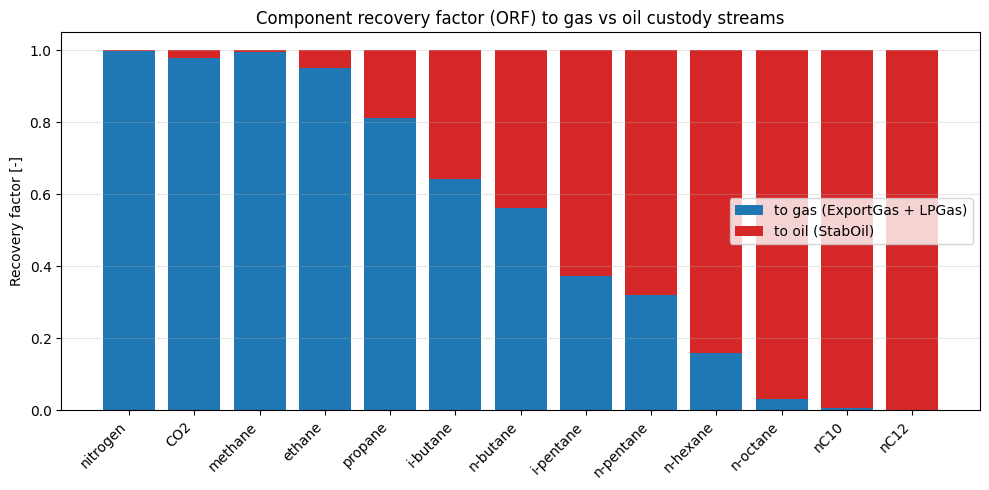

In [7]:
# Recovery factor of each component to the combined gas (ExportGas + LPGas) and to oil.
rf_gas = []
rf_oil = []
for comp in components:
    g = result.getComponentRecoveryFactor("ExportGas", comp) + result.getComponentRecoveryFactor("LPGas", comp)
    o = result.getComponentRecoveryFactor("StabOil", comp)
    rf_gas.append(g)
    rf_oil.append(o)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(components))
ax.bar(x, rf_gas, label="to gas (ExportGas + LPGas)", color="#1f77b4")
ax.bar(x, rf_oil, bottom=rf_gas, label="to oil (StabOil)", color="#d62728")
ax.set_xticks(x)
ax.set_xticklabels(components, rotation=45, ha="right")
ax.set_ylabel("Recovery factor [-]")
ax.set_ylim(0, 1.05)
ax.set_title("Component recovery factor (ORF) to gas vs oil custody streams")
ax.legend(loc="center right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
FIG_DIR = Path.cwd()
fig.savefig(FIG_DIR / "allocation_recovery_factors.png", dpi=150, bbox_inches="tight")
plt.show()

**Discussion.** The recovery-factor curve is monotone in carbon number: nitrogen, CO₂
and C1–C3 are recovered &gt;95% to gas, the split crosses ~50% around C5–C6, and C8+
is recovered almost entirely to oil. Because these factors are *frozen* from the base
case, every source that shares this slate is allocated with the **same** physically
consistent recovery — there is no double counting and the allocation always closes.

## 5. Allocation factors per well

The **allocation factor** is the fraction of a well's own production delivered to each
custody outlet (the factors for a well sum to one). The gas-rich Well-A sends most of
itself to gas; the oil-rich Well-B keeps a much larger share as stabilised oil.

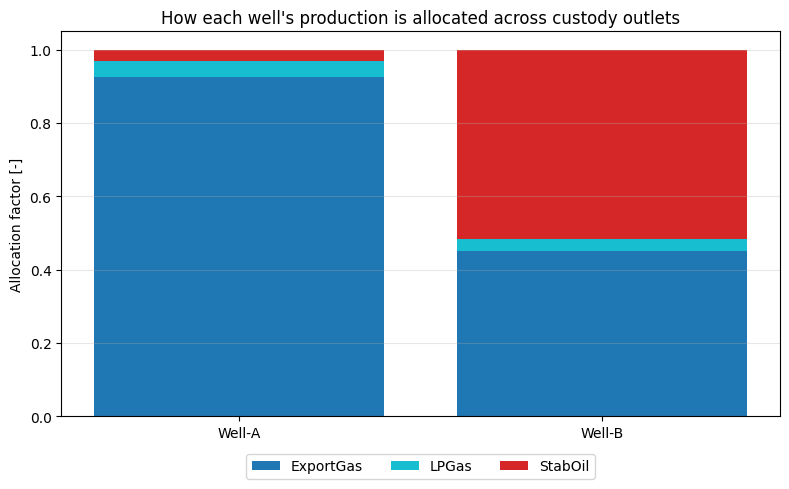

Well-A {'ExportGas': 0.926, 'LPGas': 0.045, 'StabOil': 0.03}
Well-B {'ExportGas': 0.45, 'LPGas': 0.033, 'StabOil': 0.516}


In [8]:
factors = np.array([[result.getAllocationFactor(s, c) for c in custody] for s in sources])

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(sources))
colors = ["#1f77b4", "#17becf", "#d62728"]
for ci, c in enumerate(custody):
    ax.bar(sources, factors[:, ci], bottom=bottom, label=c, color=colors[ci % len(colors)])
    bottom += factors[:, ci]
ax.set_ylabel("Allocation factor [-]")
ax.set_ylim(0, 1.05)
ax.set_title("How each well's production is allocated across custody outlets")
ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, -0.08))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "allocation_factors.png", dpi=150, bbox_inches="tight")
plt.show()

for si, s in enumerate(sources):
    print(s, {c: round(float(factors[si, ci]), 3) for ci, c in enumerate(custody)})

## 6. Mass closure and JSON export

With `enforceMassClosure` (the default), the per-source allocations sum *exactly* to the
base-case custody totals. The schema-versioned JSON is ready for downstream reporting or
agent-to-agent handoff.

In [9]:
total_in = sum(result.getSourceTotal(s, "kg/hr") for s in sources)
total_out = sum(result.getCustodyTotal(c, "kg/hr") for c in custody)
closure_pct = 100.0 * (total_out - total_in) / total_in
print("Total in : %10.1f kg/hr" % total_in)
print("Total out: %10.1f kg/hr" % total_out)
print("Mass-closure error: %.4f %%" % closure_pct)

json_str = str(result.toJson())
print("\nJSON (first 900 chars):\n")
print(json_str[:900])

Total in :   210000.0 kg/hr
Total out:   210000.0 kg/hr
Mass-closure error: 0.0000 %

JSON (first 900 chars):

{
  "schemaVersion": "1.0",
  "sources": [
    "Well-A",
    "Well-B"
  ],
  "custodyOutlets": [
    "ExportGas",
    "LPGas",
    "StabOil"
  ],
  "allocations": [
    {
      "source": "Well-A",
      "totalMolePerSec": 1662.8170788474226,
      "totalKgPerHr": 120000.00000000004,
      "custody": {
        "ExportGas": {
          "molePerSec": 1539.5163441719967,
          "kgPerHr": 101487.87115976264,
          "allocationFactor": 0.925848287076236,
          "productType": "GAS"
        },
        "LPGas": {
          "molePerSec": 74.10635824633086,
          "kgPerHr": 5816.594054229264,
          "allocationFactor": 0.04456675312578428,
          "productType": "GAS"
        },
        "StabOil": {
          "molePerSec": 49.1943764290952,
          "kgPerHr": 12695.534786008157,
          "allocationFactor": 0.029584959797979798,
          "productType": "OIL"
     

## 7. Sensitivity: changing one well's rate

A key allocation question is *how robust the split is to a change in one well's rate*.
Because the linear method **freezes** the recovery factors from a base case, we re-run the
base case at each rate so the commingled phase behaviour (and therefore the factors) is
re-evaluated. As the oil-rich Well-B ramps up, the commingled stream gets heavier, the
HP separator drops out more liquid, and the gas-rich **Well-A** has a slightly larger
share of *its own* production allocated to oil — the cross-well coupling the metering
engineer needs to understand.

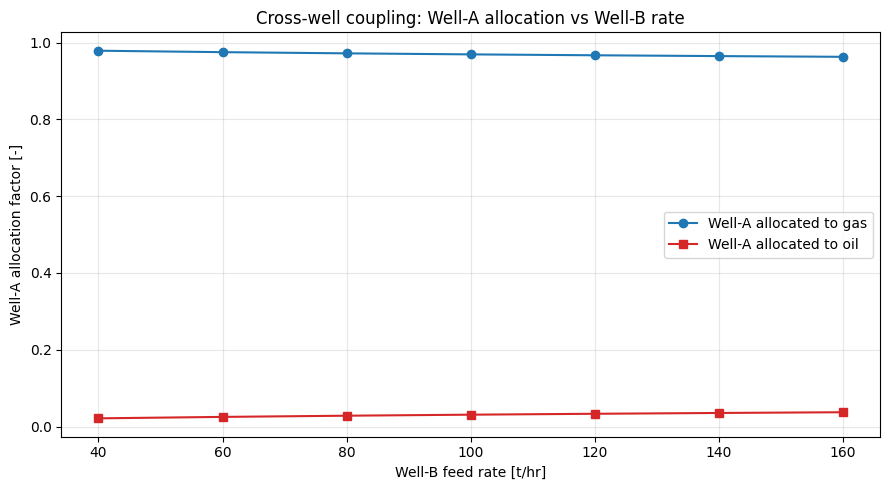

Well-B    40 t/hr  ->  Well-A gas=0.979  oil=0.021
Well-B    60 t/hr  ->  Well-A gas=0.975  oil=0.025
Well-B    80 t/hr  ->  Well-A gas=0.972  oil=0.028
Well-B   100 t/hr  ->  Well-A gas=0.969  oil=0.031
Well-B   120 t/hr  ->  Well-A gas=0.967  oil=0.033
Well-B   140 t/hr  ->  Well-A gas=0.965  oil=0.035
Well-B   160 t/hr  ->  Well-A gas=0.963  oil=0.037


In [10]:
rates_b = np.linspace(40000.0, 160000.0, 7)
a_to_gas = []
a_to_oil = []
for rb in rates_b:
    p, hh = build_process(rate_a_kghr=120000.0, rate_b_kghr=float(rb))
    r = allocate(p, hh)
    a_to_gas.append(r.getAllocationFactor("Well-A", "ExportGas") + r.getAllocationFactor("Well-A", "LPGas"))
    a_to_oil.append(r.getAllocationFactor("Well-A", "StabOil"))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rates_b / 1000.0, a_to_gas, "o-", label="Well-A allocated to gas", color="#1f77b4")
ax.plot(rates_b / 1000.0, a_to_oil, "s-", label="Well-A allocated to oil", color="#d62728")
ax.set_xlabel("Well-B feed rate [t/hr]")
ax.set_ylabel("Well-A allocation factor [-]")
ax.set_title("Cross-well coupling: Well-A allocation vs Well-B rate")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "allocation_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

for rb, g, o in zip(rates_b, a_to_gas, a_to_oil):
    print("Well-B %5.0f t/hr  ->  Well-A gas=%.3f  oil=%.3f" % (rb / 1000.0, g, o))

## 8. Pros and cons of allocation methods

| Method | How it works | Pros | Cons |
|---|---|---|---|
| **Pro-rata / uniform** | Split metered totals by an assumed ratio (well test, theoretical rate) | Trivial; no model | Ignores phase behaviour; unfair when wells differ in composition |
| **Per-source component tagging (tracer)** | Duplicate every component per source and re-run the rigorous simulation | Rigorous; captures full non-linear coupling | Cost scales with *sources × components*; must re-simulate for every scenario |
| **Linear recovery-factor proxy (this package)** | Freeze per-unit split factors from one base run, then superpose sources | Fast — scales with *components × units*, not sources; handles recycle/reflux; exact mass closure | Linearised around the base case; cross-well non-linearity needs a base-case refresh |
| **Equation-of-state re-flash per allocation** | Re-flash the commingled fluid for each ownership split | Accurate per snapshot | Expensive; no superposition; hard to audit |

**When to use the linear method:** routine, frequent allocation over many sources where
the operating point is reasonably stable between meter readings. Refresh the base case
(re-extract factors) when the commingled composition or operating envelope shifts
materially — the sensitivity study above shows when that matters. See the
[production-allocation guide](../../docs/process/production-allocation.md) for the full
method discussion and the Energy Institute *HM-96* allocation guidelines.

In [11]:
import json

results = {
    "key_results": {
        "field_gas_t_per_day": round(field_gas, 1),
        "field_oil_t_per_day": round(field_oil, 1),
        "wellA_gas_allocation_factor": round(float(factors[0, 0] + factors[0, 1]), 3),
        "wellB_oil_allocation_factor": round(float(result.getAllocationFactor("Well-B", "StabOil")), 3),
        "max_solver_residual": float(result.getMaxResidual()),
    },
    "validation": {
        "mass_closure_error_pct": round(abs(closure_pct), 4),
        "acceptance_criteria_met": bool(abs(closure_pct) < 0.01 and result.getMaxResidual() < 1e-6),
    },
    "approach": (
        "Linear recovery-factor proxy network: a two-well commingled two-stage separation "
        "process is run once with SRK EOS, frozen per-unit per-component split factors are "
        "extracted, and the export gas/oil streams are back-allocated to each well by "
        "superposition with enforced mass closure."
    ),
    "conclusions": (
        "Component recovery factors reproduce the expected ORF trend (light ends to gas, "
        "heavy ends to oil). The gas-rich well is allocated mostly to gas and the oil-rich "
        "well mostly to oil. A sensitivity on Well-B rate shows the cross-well coupling that "
        "requires periodic base-case refresh."
    ),
    "figure_captions": {
        "allocation_recovery_factors.png": "Component recovery factor (ORF) to gas vs oil custody streams.",
        "allocation_factors.png": "Allocation factor of each well across the three custody outlets.",
        "allocation_sensitivity.png": "Well-A allocation factors as Well-B feed rate varies.",
    },
}
with open("production_allocation_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

{
  "key_results": {
    "field_gas_t_per_day": 2960.5,
    "field_oil_t_per_day": 2079.5,
    "wellA_gas_allocation_factor": 0.97,
    "wellB_oil_allocation_factor": 0.516,
    "max_solver_residual": 0.0
  },
  "validation": {
    "mass_closure_error_pct": 0.0,
    "acceptance_criteria_met": true
  },
  "approach": "Linear recovery-factor proxy network: a two-well commingled two-stage separation process is run once with SRK EOS, frozen per-unit per-component split factors are extracted, and the export gas/oil streams are back-allocated to each well by superposition with enforced mass closure.",
  "conclusions": "Component recovery factors reproduce the expected ORF trend (light ends to gas, heavy ends to oil). The gas-rich well is allocated mostly to gas and the oil-rich well mostly to oil. A sensitivity on Well-B rate shows the cross-well coupling that requires periodic base-case refresh.",
  "figure_captions": {
    "allocation_recovery_factors.png": "Component recovery factor (ORF)